In [1]:
import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
fake = pd.read_csv(r"C:\Users\LIKITHA\Downloads\FakeNewsDetection\Fake.csv")
true = pd.read_csv(r"C:\Users\LIKITHA\Downloads\FakeNewsDetection\True.csv")

fake["label"] = 0
true["label"] = 1

data = pd.concat([fake, true])

data = data[['text','label']]
data = data.sample(frac=1).reset_index(drop=True)

print(data.head())

                                                text  label
0                                     Wow! Just wow!      0
1  In a bombshell revelation, The New York Times ...      0
2  SHANGHAI (Reuters) - Beijing will hire permane...      1
3  (Reuters) - In September 2014, Gilberto Velasq...      1
4  A 14 year old girl yelled:  F*ck the pizza man...      0


In [3]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    
    words = text.split()
    
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

data["text"] = data["text"].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LIKITHA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
X = data["text"]
y = data["label"]

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)

X_pad = pad_sequences(X_seq, maxlen=500)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y, test_size=0.2, random_state=42
)

In [6]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64, input_length=500))

model.add(LSTM(64))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\LIKITHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 210s 365ms/step - accuracy: 0.9614 - loss: 0.1158 - val_accuracy: 0.9833 - val_loss: 0.0547
Epoch 2/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 603s 1s/step - accuracy: 0.9765 - loss: 0.0801 - val_accuracy: 0.9945 - val_loss: 0.0233
Epoch 3/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 436s 776ms/step - accuracy: 0.9944 - loss: 0.0212 - val_accuracy: 0.9944 - val_loss: 0.0235
Epoch 4/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 3818s 7s/step - accuracy: 0.9960 - loss: 0.0154 - val_accuracy: 0.9955 - val_loss: 0.0148
Epoch 5/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 216s 384ms/step - accuracy: 0.9976 - loss: 0.0092 - val_accuracy: 0.9961 - val_loss: 0.0161


In [8]:
pred = model.predict(X_test)

pred = (pred > 0.5)

print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

281/281 ━━━━━━━━━━━━━━━━━━━━ 30s 105ms/step
Accuracy: 0.9961024498886414
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4717
           1       1.00      0.99      1.00      4263

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



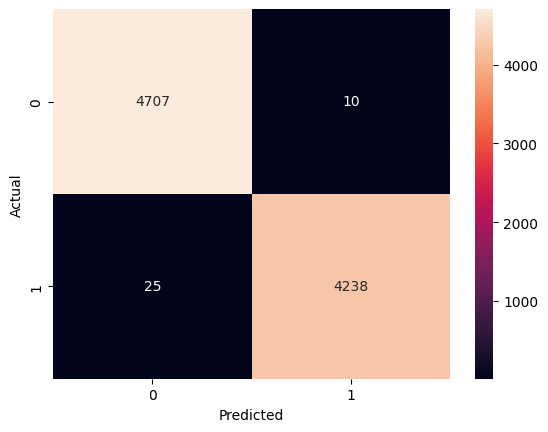

In [9]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
def predict_news(news):

    news = clean_text(news)
    seq = tokenizer.texts_to_sequences([news])
    pad = pad_sequences(seq, maxlen=500)

    prediction = model.predict(pad)

    if prediction > 0.5:
        print("Real News")
    else:
        print("Fake News")

predict_news("Government announces new economic policy")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Fake News


In [11]:
def predict_news(news):

    news = clean_text(news)
    seq = tokenizer.texts_to_sequences([news])
    pad = pad_sequences(seq, maxlen=500)

    prediction = model.predict(pad)[0][0]

    print("Prediction Score:", prediction)

    if prediction > 0.5:
        print("Real News")
    else:
        print("Fake News")

In [12]:
 predict_news("Government announces new economic policy")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Prediction Score: 0.00047067297
Fake News


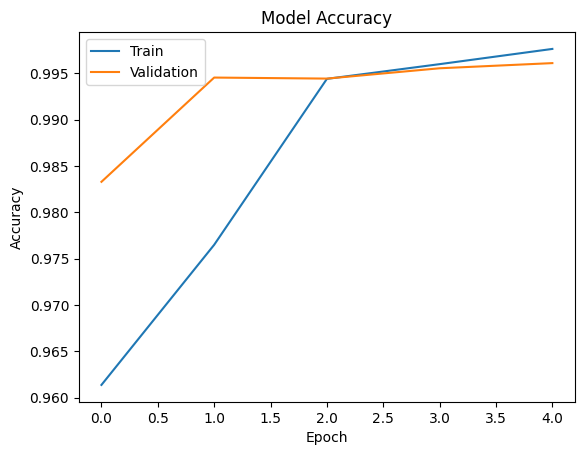

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(['Train','Validation'])

plt.show()

In [14]:
model.save("fake_news_model.h5")

In [15]:
predict_news("Scientists discover new planet")
predict_news("Aliens landed in New York yesterday")
predict_news("Government introduces new tax reforms")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Prediction Score: 0.00041490005
Fake News
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Prediction Score: 0.00032986992
Fake News
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Prediction Score: 0.010072172
Fake News


In [16]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [19]:
news = "Aliens landed in New York yesterday"

In [20]:
print("Text Analysis")

word_count = len(news.split())
char_count = len(news)
print("Word Count:", word_count)
print("Character Count:", char_count)

Text Analysis
Word Count: 6
Character Count: 35


In [22]:
news = "Aliens landed in New York yesterday"

seq = tokenizer.texts_to_sequences([news])
pad = pad_sequences(seq, maxlen=500)

prediction = model.predict(pad)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


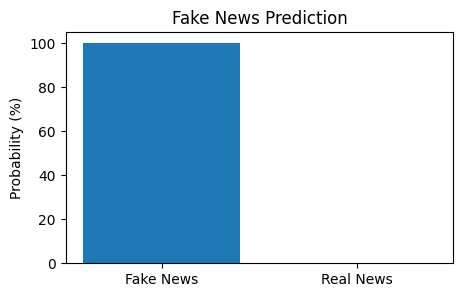

In [23]:
score = prediction[0][0]

fake_prob = round((1-score)*100,2)
real_prob = round(score*100,2)

labels = ['Fake News', 'Real News']
values = [fake_prob, real_prob]

plt.figure(figsize=(5,3))
plt.bar(labels, values)

plt.ylabel("Probability (%)")
plt.title("Fake News Prediction")

plt.show()

In [25]:
!pip install wordcloud

You should consider upgrading via the 'C:\Users\LIKITHA\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [27]:
import sys
!{sys.executable} -m pip install wordcloud

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

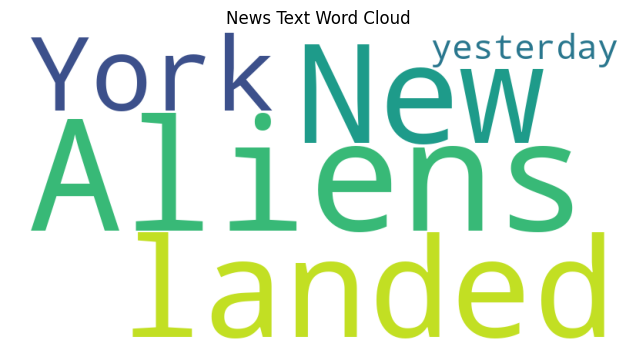

In [29]:
news = "Aliens landed in New York yesterday"

wordcloud = WordCloud(width=800, height=400,
                      background_color='white').generate(news)

plt.figure(figsize=(8,4))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("News Text Word Cloud")

plt.show()

In [30]:
!pip install textblob

You should consider upgrading via the 'C:\Users\LIKITHA\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [32]:
import sys
!{sys.executable} -m pip install textblob

   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   --------------------------------- ------ 524.3/624.3 kB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 624.3/624.3 kB 3.7 MB/s  0:00:00


In [33]:
from textblob import TextBlob

In [34]:
news = "Aliens landed in New York yesterday"

analysis = TextBlob(news)

sentiment_score = analysis.sentiment.polarity

print("Sentiment Score:", sentiment_score)

if sentiment_score > 0:
    print("News Tone: Positive 🙂")

elif sentiment_score < 0:
    print("News Tone: Negative 😡")

else:
    print("News Tone: Neutral 😐")

Sentiment Score: 0.13636363636363635
News Tone: Positive 🙂


In [35]:
def detect_category(news):

    news = news.lower()

    if "government" in news or "election" in news or "policy" in news:
        return "Politics"

    elif "match" in news or "cricket" in news or "football" in news:
        return "Sports"

    elif "technology" in news or "ai" in news or "software" in news:
        return "Technology"

    elif "market" in news or "stock" in news or "business" in news:
        return "Business"

    elif "movie" in news or "music" in news or "actor" in news:
        return "Entertainment"

    else:
        return "General News"

In [36]:
news = "Government introduces new tax reforms"

category = detect_category(news)

print("News Category:", category)

News Category: Politics


In [37]:
detect_category("India wins cricket world cup")
detect_category("New AI technology launched by Google")
detect_category("Stock market crashes today")

'Business'

In [38]:
history = []

In [39]:
news = "Aliens landed in New York yesterday"

seq = tokenizer.texts_to_sequences([news])
pad = pad_sequences(seq, maxlen=500)

prediction = model.predict(pad)

score = prediction[0][0]

if score > 0.5:
    label = "Real News"
else:
    label = "Fake News"

confidence = round(score*100,2)

history.append([news, label, confidence])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


In [40]:
df = pd.DataFrame(history, columns=["News", "Prediction", "Confidence (%)"])

print(df)

                                  News Prediction  Confidence (%)
0  Aliens landed in New York yesterday  Fake News            0.03


In [41]:
!pip install rake-nltk

You should consider upgrading via the 'C:\Users\LIKITHA\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [43]:
import sys
!{sys.executable} -m pip install rake_nltk

In [44]:
from rake_nltk import Rake

In [45]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LIKITHA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [47]:
if label == "Fake News":
    print("⚠ WARNING: This news may be misleading.")
    print("Please verify from trusted sources.")

else:
    print("✔ This news appears to be reliable.")

⚠ WARNING: This news may be misleading.
Please verify from trusted sources.


In [48]:
news = "Aliens landed in New York yesterday"

seq = tokenizer.texts_to_sequences([news])
pad = pad_sequences(seq, maxlen=500)

prediction = model.predict(pad)

score = prediction[0][0]

if score > 0.5:
    label = "Real News"
else:
    label = "Fake News"

confidence = round(score*100,2)

print("Prediction:", label)
print("Confidence:", confidence,"%")

if label == "Fake News":
    print("⚠ WARNING: This news may be misleading.")
    print("Please verify from trusted sources.")
else:
    print("✔ This news appears reliable.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Prediction: Fake News
Confidence: 0.03 %
⚠ WARNING: This news may be misleading.
Please verify from trusted sources.


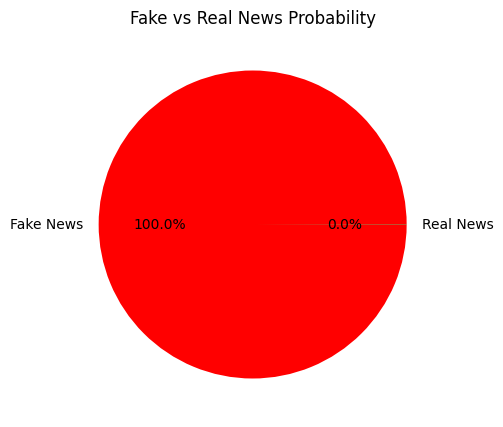

In [49]:
score = prediction[0][0]

fake_prob = round((1-score)*100,2)
real_prob = round(score*100,2)

labels = ['Fake News','Real News']
sizes = [fake_prob, real_prob]

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['red','green'])

plt.title("Fake vs Real News Probability")

plt.show()

In [50]:
!pip install yake

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 2.2.6 which is incompatible.
You should consider upgrading via the 'C:\Users\LIKITHA\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [52]:
import sys
!{sys.executable} -m pip install yake


   ---------------------------------------- 0/4 [tabulate]
   ---------- ----------------------------- 1/4 [segtok]
   ---------- ----------------------------- 1/4 [segtok]
   ---------- ----------------------------- 1/4 [segtok]
   ------------------------------ --------- 3/4 [yake]
   ------------------------------ --------- 3/4 [yake]
   ------------------------------ --------- 3/4 [yake]
   ---------------------------------------- 4/4 [yake]



In [53]:
import yake

In [54]:
news = "Aliens landed in New York yesterday"

kw_extractor = yake.KeywordExtractor(top=5)

keywords = kw_extractor.extract_keywords(news)

print("Important Words:")

for kw in keywords:
    print(kw[0])

Important Words:
York yesterday
Aliens landed
York
Aliens
yesterday


In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [56]:
news_dataset = [
    "Government announces new economic policy",
    "Scientists discover new planet",
    "Stock market crashes today",
    "New AI technology launched by Google"
]

In [57]:
news = "Government introduces new tax reforms"

texts = news_dataset + [news]

vectorizer = TfidfVectorizer()

tfidf = vectorizer.fit_transform(texts)

similarity_matrix = cosine_similarity(tfidf[-1], tfidf[:-1])

similarity_score = similarity_matrix.max()

print("News Similarity Score:", round(similarity_score,2))

News Similarity Score: 0.24


In [58]:
!pip install sumy

  Created wheel for breadability: filename=breadability-0.1.20-py2.py3-none-any.whl size=21759 sha256=74492b7c20237d573eef62e33daa385d98bde255d9390c567a905f699687fde4
  Stored in directory: c:\users\likitha\appdata\local\pip\cache\wheels\64\22\90\b84fcc30e16598db20a0d41340616dbf9b1e82bbcc627b0b33
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13794 sha256=796c5bcfe55741e8f6695e1e0033562ee02edcad448830750047f81ce9d84c7d
  Stored in directory: c:\users\likitha\appdata\local\pip\cache\wheels\fc\ab\d4\5da2067ac95b36618c629a5f93f809425700506f72c9732fac
Successfully built breadability docopt
  Attempting uninstall: setuptools
    Found existing installation: setuptools 57.4.0
    Uninstalling setuptools-57.4.0:
      Successfully uninstalled setuptools-57.4.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 2.2.6 which is incompatible.
You should consider upgrading via the 'C:\Users\LIKITHA\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [60]:
import sys
!{sys.executable} -m pip install sumy

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/4.0 MB 3.8 MB/s eta 0:00:01
   -------------------- ------------------- 2.1/4.0 MB 7.2 MB/s eta 0:00:01
   --------------------------------- ------ 3.4/4.

In [61]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer

In [63]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LIKITHA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [64]:
news = """
Scientists have discovered a new planet outside the solar system.
The planet may support life and is located 200 light years away.
Researchers believe it has water and a suitable atmosphere.
"""

parser = PlaintextParser.from_string(news, Tokenizer("english"))

summarizer = LsaSummarizer()

summary = summarizer(parser.document, 2)

print("News Summary:")

for sentence in summary:
    print(sentence)

LookupError: NLTK tokenizers are missing or the language is not supported.
Download them by following command: python -c "import nltk; nltk.download('punkt')"
Original error was:

**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - 'C:\\Users\\LIKITHA/nltk_data'
    - 'C:\\Users\\LIKITHA\\AppData\\Local\\Programs\\Python\\Python313\\nltk_data'
    - 'C:\\Users\\LIKITHA\\AppData\\Local\\Programs\\Python\\Python313\\share\\nltk_data'
    - 'C:\\Users\\LIKITHA\\AppData\\Local\\Programs\\Python\\Python313\\lib\\nltk_data'
    - 'C:\\Users\\LIKITHA\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
*********************************************************